# Ideal vs Noisy Quantum Simulation

## 1. Problem Statement
Create a 1-qubit quantum circuit containing a Hadamard gate and measurement, execute it using an ideal AerSimulator, then introduce a depolarizing error model to the Hadamard gate and compare the resulting measurement probabilities.

---

## 2. Theoretical Background & Concepts

### Quantum Circuit Simulation
Quantum circuit simulation is an essential tool in quantum computing that allows developers and researchers to design, test, and debug quantum algorithms classically before running them on physical quantum processing units (QPUs).

### Ideal vs. Noisy Simulation
- **Ideal Simulation**: Assumes perfect, closed-system unitary operations without environmental interference or control imperfections. Any variation in measurement outcomes relative to theoretical probabilities arises solely from the probabilistic nature of quantum measurement and finite statistical sampling (shot noise).
- **Noisy Simulation**: Models realistic physical interactions by injecting error channels into gates, state preparation, or measurements. This enables the evaluation of how environmental decoherence and hardware gate infidelities degrade quantum state fidelity.

### Depolarizing Noise Model
A **depolarizing channel** is a widely used quantum error model representing the loss of quantum information. For a single qubit subjected to depolarizing error with parameter $\lambda$, the quantum channel transforms the density matrix $\rho$ according to:

$$\mathcal{E}(\rho) = (1 - \lambda)\rho + \frac{\lambda}{3}\left(X\rho X + Y\rho Y + Z\rho Z\right)$$

With probability $\lambda$, the gate operation is corrupted by a randomly chosen Pauli error ($X$, $Y$, or $Z$), causing the state to decay toward a maximally mixed state. This induces deviations from ideal measurement statistics.

### Purpose of Comparing Ideal and Noisy Results
Comparing ideal and noisy simulations helps characterize circuit vulnerability to gate errors, evaluate noise-resilient algorithms, and benchmark quantum error mitigation techniques under controlled conditions.

---

## 3. Experimental Setup
- **Number of Qubits**: 1 qubit, measured into 1 classical bit.
- **Number of Shots**: 4096.
- **Quantum Operation**: Single Hadamard gate ($H$), preparing the equal superposition state $|+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}$.
- **Noise Model**: Single-qubit depolarizing error channel applied to the Hadamard gate (`'h'`).
- **Depolarizing Error Probability**: $\lambda = 0.02$ (2% error rate).
- **Target Analysis**: Comparison of measurement outcomes and probabilities for computational states $|0\rangle$ and $|1\rangle$.

---

## 4. Tools & Libraries Used
- **Qiskit**: Open-source quantum computing framework for constructing, transforming, and measuring quantum circuits.
- **Qiskit Aer (`AerSimulator`)**: High-performance quantum simulator backend for ideal and noisy circuit execution.
- **Qiskit Aer Noise (`NoiseModel`, `depolarizing_error`)**: Modules for building customized quantum noise channels and error models.
- **Matplotlib**: Python data visualization library used to render comparative probability distributions.

### Step 1: Import Required Libraries
Import `QuantumCircuit` from Qiskit, `AerSimulator`, `NoiseModel`, and `depolarizing_error` from Qiskit Aer, and `matplotlib.pyplot` for visualization.

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
import matplotlib.pyplot as plt

/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_4170/919406079.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit


### Step 2: Construct the Quantum Circuit
Initialize a 1-qubit, 1-classical-bit quantum circuit. Apply a Hadamard gate ($H$) to qubit 0 to prepare the equal superposition state $|+\rangle$, measure qubit 0 into classical bit 0, and display the circuit diagram.

In [2]:
shots = 4096

qc = QuantumCircuit(1,1)

qc.h(0)

qc.measure(0,0)

print(qc.draw())

     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


### Step 3: Run the Ideal Simulation
Instantiate an ideal `AerSimulator` backend without any noise model and execute the circuit for $N = 4096$ shots to collect baseline measurement counts.

In [3]:
ideal = AerSimulator()

ideal_counts = ideal.run(qc,shots=shots).result().get_counts()

print(ideal_counts)

{'1': 2113, '0': 1983}


### Step 4: Configure the Depolarizing Noise Model & Run Noisy Simulation
Construct a `NoiseModel` with a 2% single-qubit depolarizing error (`depolarizing_error(0.02, 1)`) attached to the `'h'` gate. Instantiate an `AerSimulator` configured with this noise model and execute the circuit for $N = 4096$ shots.

In [4]:
noise = NoiseModel()

noise.add_all_qubit_quantum_error(

    depolarizing_error(0.02,1),

    ['h']

)

noisy = AerSimulator(noise_model=noise)

noisy_counts = noisy.run(qc,shots=shots).result().get_counts()

print(noisy_counts)

{'1': 1964, '0': 2132}


### Step 5: Calculate Measurement Probabilities
Calculate empirical probabilities ($P = \frac{\text{counts}}{\text{shots}}$) for basis states `'0'` and `'1'` under both ideal and noisy simulation conditions.

In [5]:
states=['0','1']

ideal_prob=[]

noise_prob=[]

for state in states:

    ideal_prob.append(ideal_counts.get(state,0)/shots)

    noise_prob.append(noisy_counts.get(state,0)/shots)

### Step 6: Visualize the Probability Difference
Plot a side-by-side comparative bar chart to contrast the probability distributions of the ideal and noisy simulations.

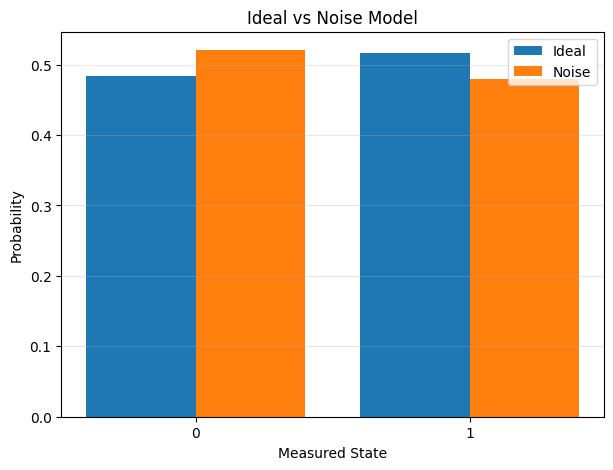

In [6]:
x=range(2)

plt.figure(figsize=(7,5))

plt.bar([i-0.2 for i in x],ideal_prob,0.4,label="Ideal")

plt.bar([i+0.2 for i in x],noise_prob,0.4,label="Noise")

plt.xticks(x,states)

plt.title("Ideal vs Noise Model")

plt.xlabel("Measured State")

plt.ylabel("Probability")

plt.legend()

plt.grid(axis='y',alpha=0.3)

plt.show()

### Step 7: Compare Ideal and Noisy Results
Display the empirical measurement probabilities for each basis state in a structured comparison table.

In [7]:
print("Comparison\n")

print(f"{'State':<8}{'Ideal':<12}{'Noise'}")

print("-"*30)

for i,state in enumerate(states):

    print(f"{state:<8}{ideal_prob[i]:<12.4f}{noise_prob[i]:.4f}")

Comparison

State   Ideal       Noise
------------------------------
0       0.4841      0.5205
1       0.5159      0.4795


### Step 8: Programmatic Summary Output
Print the final summary statements from the experiment.

In [8]:
print("\nConclusion\n")

print("The ideal simulator assumes perfect quantum operations.")

print("The noise-model simulator introduces realistic gate errors.")

print("The measured probabilities remain close to the ideal values but show slight deviations due to simulated noise.")


Conclusion

The ideal simulator assumes perfect quantum operations.
The noise-model simulator introduces realistic gate errors.
The measured probabilities remain close to the ideal values but show slight deviations due to simulated noise.


## Conclusion

- **Ideal vs. Noisy Behavior**: The ideal simulator assumes perfect, unitary operations, resulting in measurement outcomes governed purely by quantum mechanics and finite sampling statistics ($P(0) \approx 0.4841$, $P(1) \approx 0.5159$). In contrast, the noisy simulator introduces simulated gate errors (a 2% depolarizing error channel on the Hadamard gate), leading to measurable deviations in the observed probability distribution ($P(0) \approx 0.5205$, $P(1) \approx 0.4795$).
- **Influence of Noise & Sampling Variance**: The magnitude of the observed discrepancy between ideal and noisy execution is a combined consequence of the injected gate error rate ($\lambda = 0.02$) and statistical shot noise inherent to finite measurement sampling ($N = 4096$).
- **Simplified Model Nature**: The depolarizing error model is a tractable, simplified noise representation that models isotropic Pauli mixing. While valuable for exploring error dynamics and circuit sensitivity, it does not fully replicate the complex error mechanisms of real physical quantum hardware, such as thermal relaxation ($T_1$), dephasing ($T_2$), crosstalk, or state preparation and measurement (SPAM) infidelities.